# NIA T32 Landscape Analysis

This notebook queries NIH Reporter for T32 grant information and publications, prepares input files for VOSviewer bibliometric mapping, and produces charts summarizing the research landscape and measurement science gaps.

---

## Workflow overview

| Section | What it does | Requires Claude? |
|---|---|---|
| 1. Setup | Imports and paths | No |
| 2. NIH Reporter query | Fetches grant info and publications | No |
| 3. VOSviewer corpus | Builds grant abstract corpus for VOSviewer | No |
| 4. MEDLINE export | Fetches publication records from PubMed | No |
| 5. VOSviewer map analysis | Identifies measurement terms, generates charts | **Yes — see cell instructions** |

---

## Section 1 — Setup

In [1]:
# ── Install dependencies if needed ─────────────────────────────────────────────
# !pip install requests pandas openpyxl tqdm matplotlib

import requests
import pandas as pd
import matplotlib.pyplot as plt
import re
import time
from tqdm.notebook import tqdm
from pathlib import Path
import os

print(f"Working directory : {os.getcwd()}")
print(f"Contents          : {os.listdir()}")

Working directory : C:\Users\keg827\Documents\Github_Repos\FSM_NIH Reporter T32 Gap Analysis
Contents          : ['.ipynb_checkpoints', 'data', 'NIA_T32_Landscape_Analysis.ipynb', 'NIA_T32_Landscape_Analysis_v2.ipynb', 'output']


In [2]:
# ── USER SETTINGS — edit these paths to match your project folder ──────────────
CSV_PATH        = "data/grants.csv"            # Input CSV with grant numbers
GRANT_COL       = "Project Number"             # Column name containing grant numbers
OUTPUT_FILE     = "output/nih_results.xlsx"    # NIH Reporter output
OUT_DIR         = "output"                     # All output files go here
EMAIL           = "karen.gutzman@northwestern.edu" # Used by PubMed API to identify you
# ──────────────────────────────────────────────────────────────────────────────

# API constants — do not change
BASE_URL      = "https://api.reporter.nih.gov/v2"
HEADERS       = {"Content-Type": "application/json", "accept": "application/json"}
PAGE_SIZE     = 500
DELAY_SECONDS = 0.5

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print("Settings loaded.")

Settings loaded.


## Section 2 — NIH Reporter Query

In [3]:
# Load grant numbers from CSV
df_input = pd.read_csv(CSV_PATH)
print(f"Columns found : {df_input.columns.tolist()}")
print(f"Rows          : {len(df_input)}")
df_input.head()

Columns found : ['Project Number']
Rows          : 46


,Project Number
0,T32AG078114
1,T32AG049688
2,T32AG049663
3,T32AG047126
4,T32AG021890


In [4]:
# Clean and deduplicate grant numbers
grant_numbers = (
    df_input[GRANT_COL]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .drop_duplicates()
    .tolist()
)
print(f"Unique grant numbers to query: {len(grant_numbers)}")
print(grant_numbers[:5])

Unique grant numbers to query: 44
['T32AG078114', 'T32AG049688', 'T32AG049663', 'T32AG047126', 'T32AG021890']


In [5]:
# API functions

def fetch_grant_info(grant_number: str) -> list[dict]:
    """Query NIH Reporter for a single grant number, paginating across all fiscal years."""
    url = f"{BASE_URL}/projects/search"
    all_records = []
    offset = 0
    while True:
        payload = {
            "criteria": {"project_nums": [grant_number]},
            "offset": offset,
            "limit": PAGE_SIZE,
            "fields": [
                "project_num", "project_title", "fiscal_year",
                "project_start_date", "project_end_date", "award_amount",
                "agency_ic_admin", "organization", "principal_investigators",
                "program_officers", "abstract_text", "activity_code",
                "award_type", "full_study_section", "is_active", "appl_id"
            ]
        }
        try:
            resp = requests.post(url, headers=HEADERS, json=payload, timeout=30)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f"  WARNING: Error fetching grant {grant_number}: {e}")
            break
        page_results = data.get("results", [])
        all_records.extend(page_results)
        total = data.get("total")
        offset += len(page_results)
        if not page_results:
            break
        if total is not None and offset >= total:
            break
        if len(page_results) < PAGE_SIZE:
            break
    return all_records


def fetch_publications(appl_id: int, grant_number: str = "") -> list[dict]:
    """Fetch all publications for one appl_id, paging until a short/empty page."""
    url = f"{BASE_URL}/publications/search"
    all_pubs = []
    offset = 0
    page_num = 0
    while True:
        payload = {
            "criteria": {"appl_ids": [appl_id]},
            "offset": offset,
            "limit": PAGE_SIZE
        }
        try:
            resp = requests.post(url, headers=HEADERS, json=payload, timeout=30)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f"  WARNING: Error fetching publications for appl_id {appl_id}: {e}")
            break
        page_results = data.get("results", [])
        all_pubs.extend(page_results)
        page_num += 1
        offset += len(page_results)
        if page_num > 1:
            print(f"    {grant_number} appl_id {appl_id}: fetched {offset} publications so far...")
        if len(page_results) < PAGE_SIZE:
            break
        time.sleep(DELAY_SECONDS)
    return all_pubs


def flatten_grant(record: dict, queried_grant_num: str) -> dict:
    org = record.get("organization") or {}
    pis = record.get("principal_investigators") or []
    pi_names = "; ".join(
        f"{p.get('last_name', '')}, {p.get('first_name', '')}".strip(", ") for p in pis
    )
    return {
        "queried_grant_number":    queried_grant_num,
        "project_num":             record.get("project_num"),
        "appl_id":                 record.get("appl_id"),
        "project_title":           record.get("project_title"),
        "fiscal_year":             record.get("fiscal_year"),
        "project_start_date":      record.get("project_start_date"),
        "project_end_date":        record.get("project_end_date"),
        "is_active":               record.get("is_active"),
        "award_amount":            record.get("award_amount"),
        "activity_code":           record.get("activity_code"),
        "award_type":              record.get("award_type"),
        "agency_ic_admin":         (record.get("agency_ic_admin") or {}).get("abbreviation"),
        "organization_name":       org.get("org_name"),
        "organization_city":       org.get("org_city"),
        "organization_state":      org.get("org_state"),
        "principal_investigators": pi_names,
        "study_section":           (record.get("full_study_section") or {}).get("name"),
        "abstract_text":           record.get("abstract_text"),
    }


def flatten_publication(pub: dict, queried_grant_num: str, appl_id: int) -> dict:
    return {
        "queried_grant_number": queried_grant_num,
        "appl_id":              appl_id,
        "pmid":                 pub.get("pmid"),
        "title":                pub.get("title"),
        "authors":              pub.get("author_list"),
        "journal":              pub.get("journal_title") or pub.get("journal_title_abbreviation"),
        "pub_date":             pub.get("pub_date"),
        "pub_year":             pub.get("pub_year"),
        "doi":                  pub.get("doi"),
        "pubmed_url":           f"https://pubmed.ncbi.nlm.nih.gov/{pub.get('pmid')}/" if pub.get("pmid") else None,
    }

print("Functions defined.")

Functions defined.


In [6]:
# Run the main query loop
all_grants = []
all_publications = []
not_found = []

for grant_num in tqdm(grant_numbers, desc="Querying NIH Reporter"):
    records = fetch_grant_info(grant_num)
    if not records:
        not_found.append(grant_num)
        time.sleep(DELAY_SECONDS)
        continue
    appl_ids_seen = set()
    for record in records:
        all_grants.append(flatten_grant(record, grant_num))
        appl_id = record.get("appl_id")
        if appl_id and appl_id not in appl_ids_seen:
            appl_ids_seen.add(appl_id)
            time.sleep(DELAY_SECONDS)
            pubs = fetch_publications(appl_id, grant_number=grant_num)
            for pub in pubs:
                all_publications.append(flatten_publication(pub, grant_num, appl_id))
    time.sleep(DELAY_SECONDS)

print(f"\nDone!")
print(f"  Grant records     : {len(all_grants):,}")
print(f"  Publication records: {len(all_publications):,}")
if not_found:
    print(f"  Not found ({len(not_found)}): {not_found}")

Querying NIH Reporter:   0%|          | 0/44 [00:00<?, ?it/s]

    T32AG049688 appl_id 11407304: fetched 620 publications so far...
    T32AG049663 appl_id 11382776: fetched 687 publications so far...
    T32AG047126 appl_id 11335973: fetched 507 publications so far...
    T32AG021890 appl_id 11335892: fetched 1000 publications so far...
    T32AG021890 appl_id 11335892: fetched 1500 publications so far...
    T32AG021890 appl_id 11335892: fetched 1509 publications so far...
    T32AG000247 appl_id 11335238: fetched 1000 publications so far...
    T32AG000247 appl_id 11335238: fetched 1500 publications so far...
    T32AG000247 appl_id 11335238: fetched 1830 publications so far...
    T32AG019134 appl_id 11334648: fetched 1000 publications so far...
    T32AG019134 appl_id 11334648: fetched 1343 publications so far...
    T32AG049666 appl_id 11174481: fetched 715 publications so far...
    T32AG000221 appl_id 11174401: fetched 951 publications so far...
    T32AG000222 appl_id 11169990: fetched 1000 publications so far...
    T32AG000222 appl_id 1

In [7]:
# Preview and save results
df_grants = pd.DataFrame(all_grants)
df_pubs   = pd.DataFrame(all_publications)

display(df_grants.head())
display(df_pubs.head())

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    df_grants.to_excel(writer, sheet_name="Grant Info",   index=False)
    df_pubs.to_excel(  writer, sheet_name="Publications", index=False)
    if not_found:
        pd.DataFrame({"grant_number_not_found": not_found}).to_excel(
            writer, sheet_name="Not Found", index=False
        )

print(f"Saved: {Path(OUTPUT_FILE).resolve()}")

,queried_grant_number,project_num,appl_id,project_title,fiscal_year,project_start_date,project_end_date,is_active,award_amount,activity_code,award_type,agency_ic_admin,organization_name,organization_city,organization_state,principal_investigators,study_section,abstract_text
0,T32AG078114,3T32AG078114-04S1,11481795,Multidisciplinary Research Training Program in...,2026,2022-08-01T00:00:00,2027-07-31T00:00:00,True,3000,T32,3,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"Billinger, Sandra; Vidoni, Eric",None,PROJECT SUMMARY/ABSTRACT \nThis is a T32 train...
1,T32AG078114,5T32AG078114-04,11168920,Multidisciplinary Research Training Program in...,2025,2022-08-01T00:00:00,2027-07-31T00:00:00,True,228788,T32,5,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"Billinger, Sandra; Vidoni, Eric",ZAG1-ZIJ-2(M2),PROJECT SUMMARY/ABSTRACT\n This is a T32 train...
2,T32AG078114,5T32AG078114-03,10894798,Multidisciplinary Research Training Program in...,2024,2022-08-01T00:00:00,2027-07-31T00:00:00,False,317625,T32,5,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"Billinger, Sandra; Vidoni, Eric",ZAG1-ZIJ-2(M2),PROJECT SUMMARY/ABSTRACT\n This is a T32 train...
3,T32AG078114,5T32AG078114-02,10672283,Multidisciplinary Research Training Program in...,2023,2022-08-01T00:00:00,2027-07-31T00:00:00,False,295454,T32,5,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"BURNS, JEFFREY; Billinger, Sandra",ZAG1-ZIJ-2(M2),PROJECT SUMMARY/ABSTRACT\n This is a T32 train...
4,T32AG078114,1T32AG078114-01,10496109,Multidisciplinary Research Training Program in...,2022,2022-08-01T00:00:00,2027-07-31T00:00:00,False,294308,T32,1,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"BURNS, JEFFREY; Billinger, Sandra",Special Emphasis Panel[ZAG1 ZIJ-2 (M2)],PROJECT SUMMARY/ABSTRACT\n This is a T32 train...


,queried_grant_number,appl_id,pmid,title,authors,journal,pub_date,pub_year,doi,pubmed_url
0,T32AG078114,11481795,39132486,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/39132486/
1,T32AG078114,11481795,40568661,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/40568661/
2,T32AG078114,11481795,40727873,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/40727873/
3,T32AG078114,11481795,39314981,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/39314981/
4,T32AG078114,11481795,39376152,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/39376152/


Saved: C:\Users\keg827\Documents\Github_Repos\FSM_NIH Reporter T32 Gap Analysis\output\nih_results.xlsx


In [8]:
# Summary statistics
print("Grant counts by fiscal year:")
display(df_grants["fiscal_year"].value_counts().sort_index())

if "award_amount" in df_grants.columns:
    print(f"\nTotal award amount: ${df_grants['award_amount'].sum():,.0f}")

print("\nPublications per grant (top 10):")
display(
    df_pubs.groupby("queried_grant_number")["pmid"]
    .count().sort_values(ascending=False).head(10).rename("pub_count")
)

Grant counts by fiscal year:


fiscal_year
1985     2
1986     2
1987     4
1988     2
1989     3
1990     3
1991     3
1992     5
1993     5
1994     5
1995     7
1996     7
1997     7
1998     8
1999     8
2000     9
2001     9
2002     9
2003    10
2004    10
2005    11
2006    12
2007    11
2008    13
2009    13
2010    13
2011    12
2012    13
2013    12
2014    15
2015    19
2016    22
2017    35
2018    24
2019    23
2020    27
2021    36
2022    39
2023    44
2024    43
2025    40
2026     7
Name: count, dtype: int64


Total award amount: $196,658,870

Publications per grant (top 10):


queried_grant_number
T32AG000247    1830
T32AG000181    1547
T32AG021890    1509
T32AG000114    1473
T32AG019134    1343
T32AG023481    1259
T32AG000029    1158
T32AG000222    1082
T32AG000221     951
T32AG049676     794
Name: pub_count, dtype: int64

## Section 3 — VOSviewer Corpus (Grant Abstracts)

Produces a plain-text corpus file from grant titles and abstracts for VOSviewer term co-occurrence mapping.

In [9]:
# Load and deduplicate grant data
df = pd.read_excel(OUTPUT_FILE, sheet_name="Grant Info", dtype=str)
print(f"Rows loaded: {len(df)}")

def core_grant_num(val):
    """Strip leading digit and trailing -XX suffix, e.g. 5T32AG012345-10 → T32AG012345."""
    if not isinstance(val, str):
        return val
    val = re.sub(r"^\d+", "", val.strip())
    val = re.sub(r"-\d+[A-Z]?$", "", val)
    return val

df["core_grant"] = df["project_num"].apply(core_grant_num)
df_unique = (
    df.sort_values("fiscal_year", ascending=True)
      .drop_duplicates(subset="core_grant", keep="last")
)

has_abstract = (
    df_unique["abstract_text"].dropna().astype(str).str.strip().str.len().gt(0).sum()
    if "abstract_text" in df_unique.columns else 0
)
print(f"Unique grants   : {len(df_unique)}")
print(f"With abstracts  : {has_abstract}")
print(f"Without abstracts: {len(df_unique) - has_abstract}")

Rows loaded: 602
Unique grants   : 109
With abstracts  : 102
Without abstracts: 7


In [10]:
# Clean text and build corpus

BOILERPLATE_HEADERS = [
    r"PROJECT SUMMARY/?ABSTRACT", r"PROJECT SUMMARY", r"ABSTRACT",
    r"DESCRIPTION\s*\(provided by applicant\)",
    r"DESCRIPTION\s*\(provided by the applicant\)",
    r"PUBLIC HEALTH RELEVANCE", r"RELEVANCE\s*\(See instructions\)",
    r"Narrative",
]

def clean_text(text) -> str:
    """Strip HTML, non-ASCII, NIH boilerplate headers, and extra whitespace."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    for pattern in BOILERPLATE_HEADERS:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip()

corpus_lines = []
titles_lines = []
for _, row in df_unique.iterrows():
    title    = clean_text(row.get("project_title", ""))
    abstract = clean_text(row.get("abstract_text", ""))
    combined = f"{title}. {abstract}".strip(". ")
    if combined:
        corpus_lines.append(combined)
    if title:
        titles_lines.append(title)

corpus_path = Path(OUT_DIR) / "vosviewer_corpus.txt"
titles_path = Path(OUT_DIR) / "vosviewer_titles.txt"
corpus_path.write_text("\n".join(corpus_lines), encoding="utf-8")
titles_path.write_text("\n".join(titles_lines), encoding="utf-8")

print(f"Corpus file : {len(corpus_lines)} documents → {corpus_path}")
print(f"Titles file : {len(titles_lines)} documents → {titles_path}")
print("\nSample (first entry):")
print(corpus_lines[0][:300] + "..." if corpus_lines else "(none)")

Corpus file : 109 documents → output\vosviewer_corpus.txt
Titles file : 109 documents → output\vosviewer_titles.txt

Sample (first entry):
MULTIDISCIPLINARY RESEARCH TRAINING IN AGING...


In [11]:
# Save VOSviewer thesaurus file (stopwords)
# These generic training-grant terms clutter the VOSviewer map and should be suppressed.
# Load in VOSviewer via the Thesaurus file option during map creation.

import csv

CUSTOM_STOPWORDS = [
    "addition", "advantage", "aim", "along", "also", "among",
    "area", "aspect", "available", "background", "basis", "broad",
    "career", "center", "challenge", "change", "combination", "commitment",
    "completion", "confer", "consistent", "continuation", "country", "current",
    "date", "decade", "department", "depth", "detail", "development",
    "director", "effort", "engagement", "environment", "evaluation",
    "excellence", "excellent", "experience", "experiential", "expertise",
    "facility", "field", "focus", "foundation", "fund", "future",
    "goal", "grant", "high", "highest", "home", "impart",
    "input", "institute", "integrated", "interface", "laboratory",
    "leadership", "leverage", "linkage", "major", "member", "mentor",
    "mentoring", "need", "new", "office", "order", "outstanding",
    "overall", "overarching", "perspective", "pipeline", "plan",
    "policy", "pool", "preparation", "primary", "priority", "program",
    "project", "provide", "range", "recruitment", "related", "relationship",
    "relevant", "report", "request", "research", "resource", "role",
    "school", "seminar", "significant", "solid", "specific", "strength",
    "strong", "structure", "substantive", "summary", "support", "synergy",
    "teaching", "term", "time", "total", "track", "train", "trainer",
    "training", "translation", "university", "use", "variety", "well", "work",
]

thesaurus_path = Path(OUT_DIR) / "vosviewer_thesaurus.txt"
with open(thesaurus_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f, delimiter="\t")
    writer.writerow(["label", "replace by"])
    for word in sorted(CUSTOM_STOPWORDS):
        writer.writerow([word, ""])

print(f"Thesaurus file saved: {thesaurus_path}")
print(f"({len(CUSTOM_STOPWORDS)} stopwords)")

Thesaurus file saved: output\vosviewer_thesaurus.txt
(118 stopwords)


## Section 4 — PubMed MEDLINE Export

Fetches full MEDLINE-format records for all publications associated with the grants.
Load the output file into VOSviewer via:
**Create → Bibliographic data → PubMed → select `grant_publications_medline.txt`**

In [12]:
# Fetch MEDLINE records from PubMed for all publication PMIDs
BATCH_SIZE = 200
DELAY      = 0.4

df_pubs = pd.read_excel(OUTPUT_FILE, sheet_name="Publications", dtype=str)
print(f"Publications loaded: {len(df_pubs):,}")

pmids = (
    df_pubs["pmid"]
    .dropna().astype(str).str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .loc[lambda s: s != ""]
    .drop_duplicates().tolist()
)
print(f"Unique PMIDs to fetch: {len(pmids):,}")


def fetch_medline_batch(pmid_batch: list[str]) -> str:
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
    params = {
        "db": "pubmed", "id": ",".join(pmid_batch),
        "rettype": "medline", "retmode": "text",
        "tool": "NIA_T32_LandscapeAnalysis", "email": EMAIL,
    }
    try:
        resp = requests.get(url, params=params, timeout=60)
        resp.raise_for_status()
        return resp.text
    except Exception as e:
        print(f"  WARNING: {e}")
        return ""


medline_path = Path(OUT_DIR) / "grant_publications_medline.txt"
batches = [pmids[i:i+BATCH_SIZE] for i in range(0, len(pmids), BATCH_SIZE)]
total_fetched = 0

with open(medline_path, "w", encoding="utf-8") as f:
    for i, batch in enumerate(batches):
        print(f"  Batch {i+1}/{len(batches)}  ({total_fetched:,} records written)...")
        text = fetch_medline_batch(batch)
        if text:
            f.write(text)
            total_fetched += text.count("\nPMID-") + (1 if text.startswith("PMID-") else 0)
        time.sleep(DELAY)

print(f"\nDone! {total_fetched:,} records saved to {medline_path}")

Publications loaded: 22,306
Unique PMIDs to fetch: 4,514
  Batch 1/23  (0 records written)...
  Batch 2/23  (200 records written)...
  Batch 3/23  (400 records written)...
  Batch 4/23  (600 records written)...
  Batch 5/23  (800 records written)...
  Batch 6/23  (1,000 records written)...
  Batch 7/23  (1,200 records written)...
  Batch 8/23  (1,400 records written)...
  Batch 9/23  (1,599 records written)...
  Batch 10/23  (1,799 records written)...
  Batch 11/23  (1,999 records written)...
  Batch 12/23  (2,199 records written)...
  Batch 13/23  (2,399 records written)...
  Batch 14/23  (2,599 records written)...
  Batch 15/23  (2,798 records written)...
  Batch 16/23  (2,998 records written)...
  Batch 17/23  (3,198 records written)...
  Batch 18/23  (3,398 records written)...
  Batch 19/23  (3,598 records written)...
  Batch 20/23  (3,798 records written)...
  Batch 21/23  (3,998 records written)...
  Batch 22/23  (4,198 records written)...
  Batch 23/23  (4,397 records written)..

## Section 5 — VOSviewer Map Analysis

---
### ⚠️ CLAUDE-ASSISTED STEP

**Before running the cells in this section, you need to:**

1. Run VOSviewer on `grant_publications_medline.txt` (or your updated MEDLINE file)
2. Export the VOSviewer **map file** (File → Export → Map file) and save it to your output folder
3. **Share the map file with Claude** and ask:

> *"Here is my new VOSviewer map file. Please identify the measurement and psychometrics terms, flag any false positives, name each cluster and provide a cluster_names dictionary, and produce an updated `measurement_psychometric_terms_v2.csv` and `false_positive_terms.csv`."*

Claude will return:
- An updated `measurement_psychometric_terms_v2.csv` (genuine terms with cluster assignments)
- An updated `false_positive_terms.csv` (terms to exclude and why)
- Updated `cluster_names` dictionary to paste into the settings cell below

Save both CSVs to your output folder before running the cells below.

---

In [13]:
# ── USER SETTINGS for this section ────────────────────────────────────────────
MAP_FILE  = "output/vosviewer_map_file_pubs.txt"         # VOSviewer map file export
MEAS_FILE = "output/measurement_psychometric_terms_v2.csv" # From Claude
# ─────────────────────────────────────────────────────────────────────────────

# ── CLUSTER NAMES — paste updated dict from Claude if you re-ran VOSviewer ────
# Note: VOSviewer may renumber clusters on each run.
# If you re-ran VOSviewer, ask Claude for an updated cluster_names dict.
cluster_names = {
    1:  "Clinical care & caregiving (catch-all)",
    2:  "Physical function, fatigue & mobility",
    3:  "Neuroinflammation & mouse models",
    4:  "Cell biology & molecular signaling",
    5:  "Neurodegeneration & brain imaging",
    6:  "Alzheimer's & protein pathology",
    7:  "Bone density, genetics & body composition",
    8:  "Skeletal muscle & metabolic physiology",
    9:  "Thermoregulation & cardiovascular physiology",
    10: "Epigenetics, TDP-43 & COVID",
    11: "Cell signaling & inhibition pathways",
    12: "Mitochondria & oxidative biology",
    13: "Cancer, imaging & clinical coding",
    14: "Knee osteoarthritis & pain",
    15: "Gene expression & stem cell biology",
    16: "Neurological disorders & infectious disease",
    17: "Endocrinology & diet",
    18: "Immunology & tumor biology",
    19: "Genetics & hematopoiesis",
    20: "Ophthalmology & glaucoma",
    21: "Cell death pathways",
    22: "Hormones & competition",
    23: "Miscellaneous", 24: "Miscellaneous", 25: "Miscellaneous",
}
# ─────────────────────────────────────────────────────────────────────────────

df_map  = pd.read_csv(MAP_FILE, sep="\t")
df_map['label'] = df_map['label'].astype(str)
df_map["cluster_name"] = df_map["cluster"].map(cluster_names)
meas_df = pd.read_csv(MEAS_FILE)

print(f"Map file loaded  : {len(df_map)} terms, {df_map['cluster'].nunique()} clusters")
print(f"Measurement terms: {len(meas_df)}")

Map file loaded  : 4406 terms, 25 clusters
Measurement terms: 72


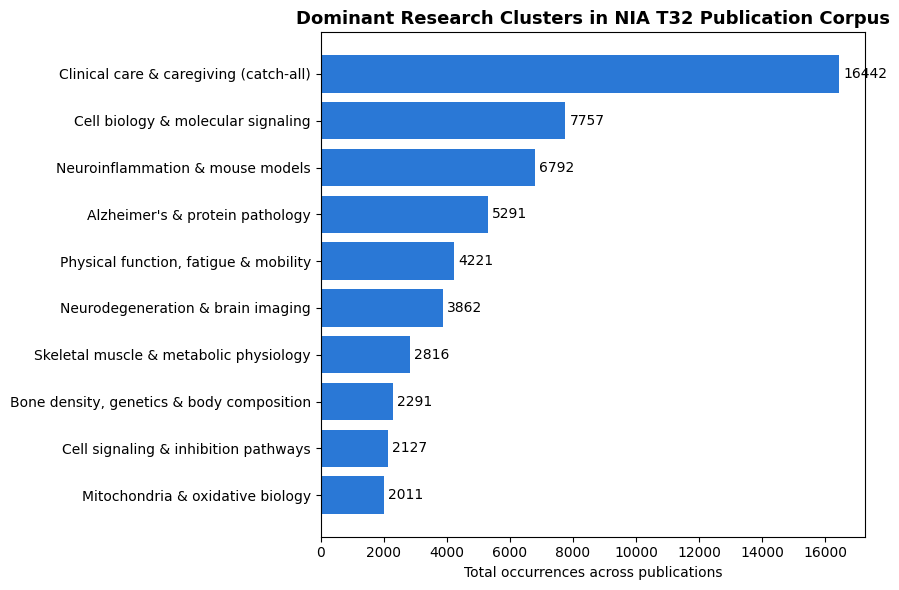

Saved: chart_dominant_clusters.png


In [14]:
# ── CHART 1: Dominant Research Clusters ───────────────────────────────────────

cluster_totals = (
    df_map.groupby(["cluster", "cluster_name"])["weight<Occurrences>"]
    .sum().reset_index()
    .sort_values("weight<Occurrences>", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    cluster_totals["cluster_name"][::-1],
    cluster_totals["weight<Occurrences>"][::-1],
    color="#2a78d6"
)
ax.set_xlabel("Total occurrences across publications")
ax.set_title("Dominant Research Clusters in NIA T32 Publication Corpus",
             fontsize=13, fontweight="bold")
ax.bar_label(bars, padding=3, fmt="%.0f")
plt.tight_layout()
plt.savefig(Path(OUT_DIR) / "chart_dominant_clusters.png", dpi=150)
plt.show()
print("Saved: chart_dominant_clusters.png")

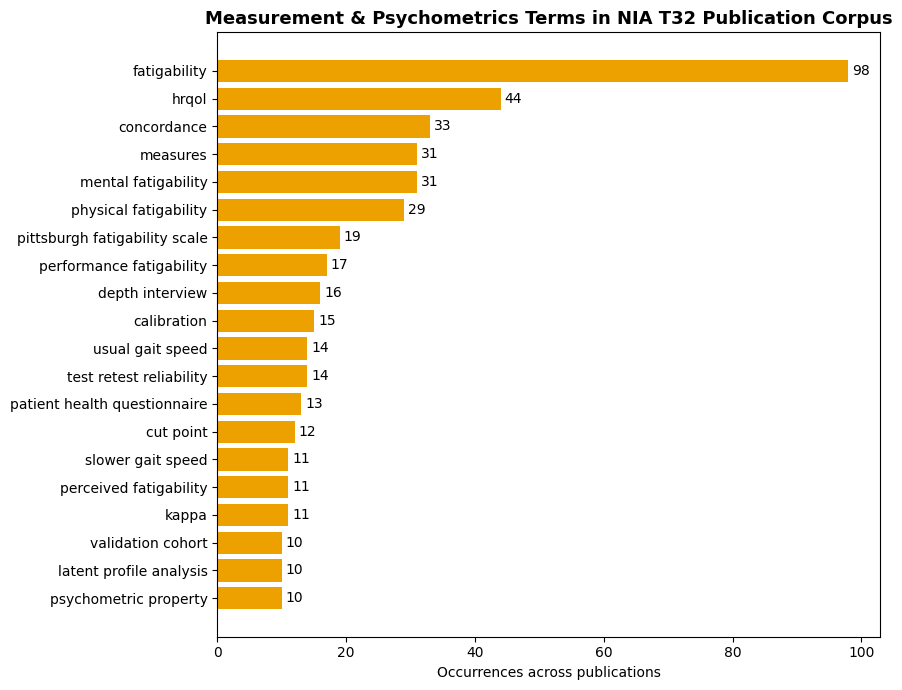

Saved: chart_measurement_terms.png


In [15]:
# ── CHART 2: Measurement & Psychometrics Terms ────────────────────────────────

top_meas = meas_df.nlargest(20, "occurrences")

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    top_meas["term"][::-1],
    top_meas["occurrences"][::-1],
    color="#eda100"
)
ax.set_xlabel("Occurrences across publications")
ax.set_title("Measurement & Psychometrics Terms in NIA T32 Publication Corpus",
             fontsize=13, fontweight="bold")
ax.bar_label(bars, padding=3, fmt="%.0f")
plt.tight_layout()
plt.savefig(Path(OUT_DIR) / "chart_measurement_terms.png", dpi=150)
plt.show()
print("Saved: chart_measurement_terms.png")

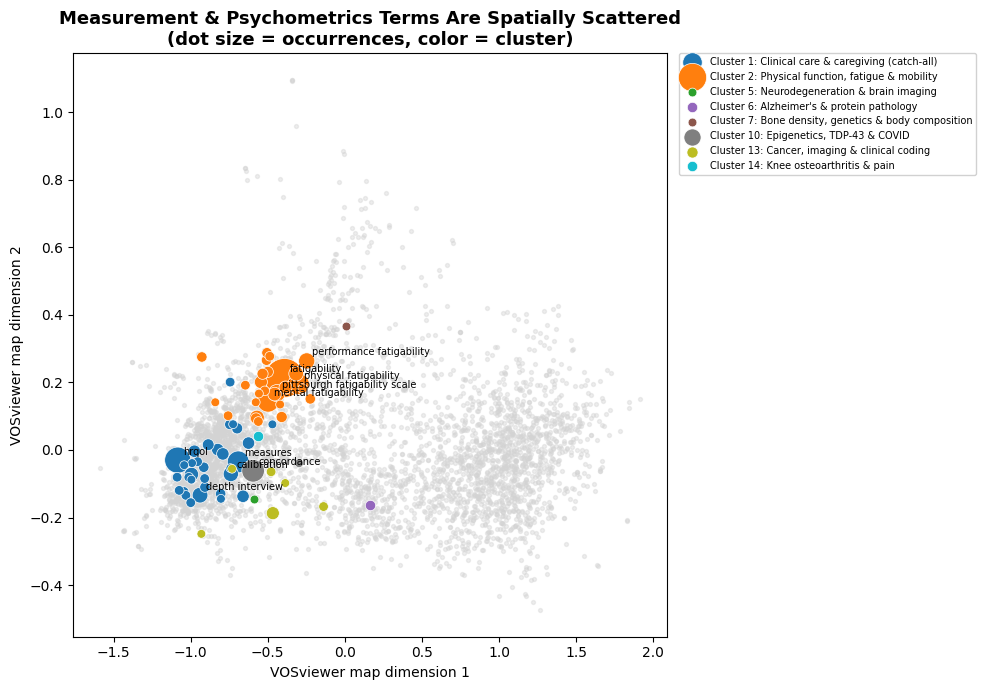

Saved: chart_measurement_terms_spatial.png


In [16]:
# ── CHART 3: Spatial scatter of measurement terms on the VOSviewer map ─────────

map_coords = df_map[["label", "x", "y"]].rename(columns={"label": "term"})
meas_spatial = meas_df.merge(map_coords, on="term", how="left")

unique_clusters = sorted(meas_spatial["cluster"].unique())
palette = plt.colormaps["tab10"].resampled(len(unique_clusters))
cluster_color_map = {c: palette(i) for i, c in enumerate(unique_clusters)}

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df_map["x"], df_map["y"], s=8, color="lightgray", alpha=0.4, zorder=1)

for c in unique_clusters:
    subset = meas_spatial[meas_spatial["cluster"] == c]
    ax.scatter(
        subset["x"], subset["y"],
        s=subset["occurrences"] * 8,
        color=cluster_color_map[c],
        edgecolor="white", linewidth=0.5,
        label=f"Cluster {c}: {cluster_names.get(c, 'Unknown')}",
        zorder=3
    )

for _, row in meas_spatial.nlargest(10, "occurrences").iterrows():
    ax.annotate(row["term"], (row["x"], row["y"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")

ax.set_title(
    "Measurement & Psychometrics Terms Are Spatially Scattered\n(dot size = occurrences, color = cluster)",
    fontsize=13, fontweight="bold")
ax.set_xlabel("VOSviewer map dimension 1")
ax.set_ylabel("VOSviewer map dimension 2")
ax.legend(loc="upper left", fontsize=7, framealpha=0.9,
          bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(Path(OUT_DIR) / "chart_measurement_terms_spatial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_measurement_terms_spatial.png")

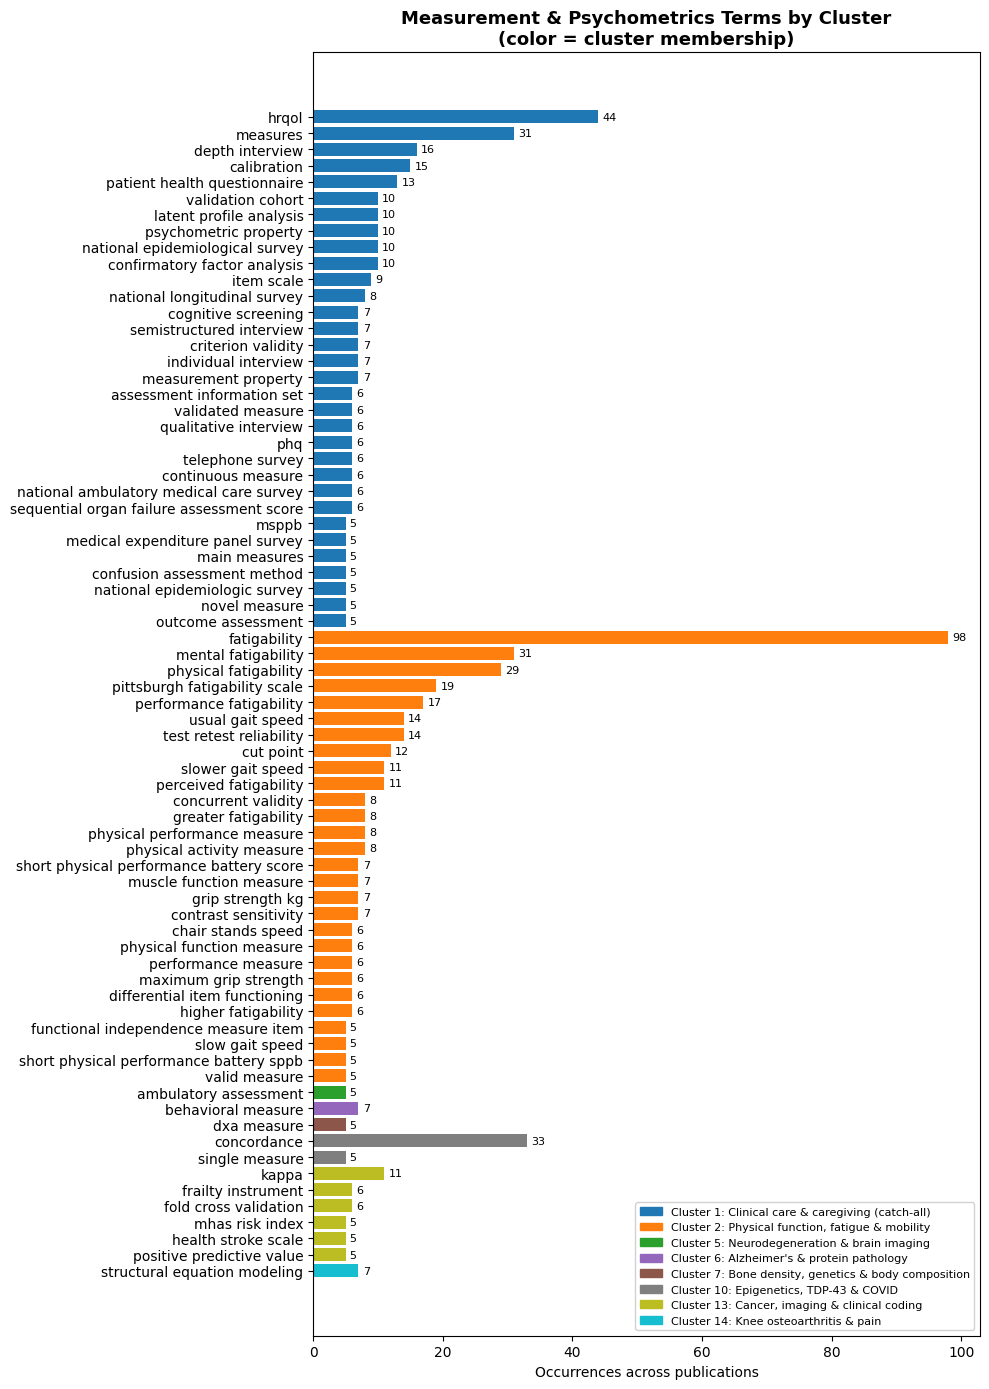

Saved: chart_measurement_terms_by_cluster.png


In [17]:
# ── CHART 4: Measurement Terms colored by cluster (horizontal bar) ─────────────

meas_by_cluster = meas_df.sort_values(["cluster", "occurrences"], ascending=[True, False])
bar_colors = meas_by_cluster["cluster"].map(cluster_color_map)

fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(
    meas_by_cluster["term"],
    meas_by_cluster["occurrences"],
    color=bar_colors
)
ax.set_xlabel("Occurrences across publications")
ax.set_title(
    "Measurement & Psychometrics Terms by Cluster\n(color = cluster membership)",
    fontsize=13, fontweight="bold")
ax.bar_label(bars, padding=3, fmt="%.0f", fontsize=8)
ax.invert_yaxis()

legend_handles = [plt.Rectangle((0,0),1,1, color=cluster_color_map[c]) for c in unique_clusters]
legend_labels  = [f"Cluster {c}: {cluster_names.get(c, 'Unknown')}" for c in unique_clusters]
ax.legend(legend_handles, legend_labels, loc="lower right", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig(Path(OUT_DIR) / "chart_measurement_terms_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_measurement_terms_by_cluster.png")

In [18]:
# ── Summary statistics ─────────────────────────────────────────────────────────

total_occ = df_map["weight<Occurrences>"].sum()
meas_occ  = meas_df["occurrences"].sum()

print(f"Total terms in map       : {len(df_map):,}")
print(f"Total occurrences        : {total_occ:,}")
print(f"Measurement term occurrences: {meas_occ:,}  ({meas_occ/total_occ*100:.2f}% of total)")
print(f"Unique measurement terms : {len(meas_df)}")

print("\nMeasurement terms by cluster:")
display(
    meas_df.groupby(["cluster", "cluster_name"])["occurrences"]
    .agg(n_terms="count", total_occ="sum")
    .sort_values("total_occ", ascending=False)
)

Total terms in map       : 4,406
Total occurrences        : 65,044
Measurement term occurrences: 776  (1.19% of total)
Unique measurement terms : 72

Measurement terms by cluster:


,,n_terms,total_occ
cluster,cluster_name,,
2,"Physical function, fatigue & mobility",28,372
1,Clinical care & caregiving (catch-all),32,304
13,"Cancer, imaging & clinical coding",6,38
10,"Epigenetics, TDP-43 & COVID",2,38
14,Knee osteoarthritis & pain,1,7
6,Alzheimer's & protein pathology,1,7
5,Neurodegeneration & brain imaging,1,5
7,"Bone density, genetics & body composition",1,5


---
### ⚠️ CLAUDE-ASSISTED STEP — Updating after a new VOSviewer run

If you re-ran VOSviewer with additional publications and have a new map file, do the following before re-running Section 5:

1. Export the new VOSviewer map file and save it to your output folder
2. Share both the **new map file** and the **existing `measurement_psychometric_terms_v2.csv`** with Claude and ask:

> *"Here is my updated VOSviewer map file and my existing measurement terms CSV. Please check for new measurement-related terms that weren't in the previous run, flag any that have changed clusters, and produce an updated `measurement_psychometric_terms_v2.csv`. Also give me an updated `cluster_names` dictionary to paste into the notebook."*

3. Replace `measurement_psychometric_terms_v2.csv` in your output folder with the updated version
4. Paste the updated `cluster_names` dictionary into the settings cell at the top of Section 5
5. Re-run all Section 5 cells

---